In [2]:
import os

for root, dirs, files in os.walk('/kaggle/input/garbage-classification-v2/original'):
    level = root.replace('/kaggle/input/garbage-classification-v2/original', '').count(os.sep)
    indent = ' ' * 2 * level
    if level == 0:
        print(indent + os.path.basename(root) + '/')
    else:
        print(indent + os.path.basename(root))
    
    if level >= 1:
        break

In [6]:
import os

for root, dirs, files in os.walk('/kaggle/input/datasets/sumn2u/garbage-classification-v2/original'):
    level = root.replace('/kaggle/input/datasets/sumn2u/garbage-classification-v2/original', '').count(os.sep)
    indent = ' ' * 2 * level
    print(indent + os.path.basename(root) + ('/' if level == 0 else ''))
    
   

original/
  metal
  glass
  biological
  paper
  battery
  trash
  cardboard
  shoes
  clothes
  plastic


In [8]:
import os

base_path = '/kaggle/input/datasets/farzadnekouei/trash-type-image-dataset/TrashType_Image_Dataset'
print(f" {os.path.basename(base_path)}/")
for item in sorted(os.listdir(base_path)):
    item_path = os.path.join(base_path, item)
    if os.path.isdir(item_path):
        # Count images in each category
        num_images = len([f for f in os.listdir(item_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        print(f"   {item}/ ({num_images} images)")

 TrashType_Image_Dataset/
   cardboard/ (403 images)
   glass/ (501 images)
   metal/ (410 images)
   paper/ (594 images)
   plastic/ (482 images)
   trash/ (137 images)


In [1]:
import os
import shutil
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models
from PIL import Image
from collections import defaultdict
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
 
 
#  paths 
 
TRASHNET_ROOT  = "/kaggle/input/datasets/farzadnekouei/trash-type-image-dataset/TrashType_Image_Dataset"
GARBAGEV2_ROOT = "/kaggle/input/datasets/sumn2u/garbage-classification-v2/original"
MERGED_DIR     = "/kaggle/working/merged_dataset"
SAVE_PATH      = "/kaggle/working/best_model.pth"
UNCERTAIN_DIR  = "/kaggle/working/uncertain_samples"
 
#  label maps 
 
CLASSES     = ["recyclable", "organic", "e_waste", "hazardous"]
CLASS_INDEX = {c: i for i, c in enumerate(CLASSES)}
 
# trashnet 
TRASHNET_MAP = {
    "cardboard": "recyclable",
    "glass":     "recyclable",
    "metal":     "recyclable",
    "paper":     "recyclable",
    "plastic":   "recyclable",
    "trash":     "hazardous",
}
 
# garbagev2
GARBAGEV2_MAP = {
    "metal":      "recyclable",
    "glass":      "recyclable",
    "paper":      "recyclable",
    "cardboard":  "recyclable",
    "plastic":    "recyclable",
    "biological": "organic",
    "battery":    "e_waste",
}
 
#  confidence thresholds 
 
CONFIDENCE_HIGH = 0.80
CONFIDENCE_LOW  = 0.50
FALLBACK_CLASS  = "uncertain"
 
#  hyperparameters 
 
BATCH_SIZE    = 32
NUM_WORKERS   = 4
VAL_SPLIT     = 0.20
PHASE1_LR     = 1e-3
PHASE1_EPOCHS = 8
PHASE2_LR     = PHASE1_LR / 10
PHASE2_EPOCHS = 4
 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {DEVICE}")
 

device: cuda


In [2]:
#  merge datasets into a single  structure

 
def _copy_folder(src_dir, dest_parent, label_map, source_tag):
    copied, skipped = 0, 0
    for folder in sorted(os.listdir(src_dir)):
        folder_path = os.path.join(src_dir, folder)
        if not os.path.isdir(folder_path):
            continue
        parent_class = label_map.get(folder)
        if parent_class is None:
            print(f"  [skip] {source_tag}/{folder} — no mapping")
            skipped += 1
            continue
        dest = os.path.join(dest_parent, parent_class)
        os.makedirs(dest, exist_ok=True)
        for fname in os.listdir(folder_path):
            if not fname.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):
                continue
            # prefix with source+folder to avoid name collisions
            new_name = f"{source_tag}_{folder}_{fname}"
            shutil.copy2(
                os.path.join(folder_path, fname),
                os.path.join(dest, new_name),
            )
            copied += 1
    return copied, skipped
 
 
def build_merged_dataset():
    if os.path.exists(MERGED_DIR):
        print("merged dataset already exists, skipping copy")
        return
 
    os.makedirs(MERGED_DIR, exist_ok=True)
    print("building merged dataset...")
 
    c1, s1 = _copy_folder(TRASHNET_ROOT,  MERGED_DIR, TRASHNET_MAP,  "trashnet")
    c2, s2 = _copy_folder(GARBAGEV2_ROOT, MERGED_DIR, GARBAGEV2_MAP, "garbagev2")
 
    print(f"  trashnet:  {c1} images copied, {s1} folders skipped")
    print(f"  garbagev2: {c2} images copied, {s2} folders skipped")
 
    for cls in CLASSES:
        cls_dir = os.path.join(MERGED_DIR, cls)
        n = len(os.listdir(cls_dir)) if os.path.exists(cls_dir) else 0
        print(f"  {cls}: {n} total images")
 

In [3]:
# dataset & dataloaders

def get_transforms(train=True):
    if train:
        return transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.RandomResizedCrop(224),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])
    return transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
 
 
class FlatWasteDataset(Dataset):
    """
    Reads merged_dataset/<parent_class>/<image files>.
    Returns (image_tensor, label_int, class_name_str).
    """
 
    def __init__(self, root, transform=None):
        self.transform = transform
        self.samples = []   # (path, label_idx, class_name)
 
        for cls in sorted(os.listdir(root)):
            cls_dir = os.path.join(root, cls)
            if not os.path.isdir(cls_dir):
                continue
            if cls not in CLASS_INDEX:
                continue
            idx = CLASS_INDEX[cls]
            for fname in sorted(os.listdir(cls_dir)):
                if not fname.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):
                    continue
                self.samples.append((os.path.join(cls_dir, fname), idx, cls))
 
        print(f"FlatWasteDataset: {len(self.samples)} images")
 
    def __len__(self):
        return len(self.samples)
 
    def __getitem__(self, idx):
        path, label, cls_name = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label, cls_name
 
 
def collate_fn(batch):
    images, labels, names = zip(*batch)
    return torch.stack(images), torch.tensor(labels), list(names)
 
 
def get_dataloaders():
    train_ds = FlatWasteDataset(MERGED_DIR, transform=get_transforms(train=True))
    val_ds   = FlatWasteDataset(MERGED_DIR, transform=get_transforms(train=False))
 
    n_total = len(train_ds)
    n_val   = int(n_total * VAL_SPLIT)
    indices = torch.randperm(n_total).tolist()
 
    train_loader = DataLoader(
        Subset(train_ds, indices[n_val:]),
        batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn,
    )
    val_loader = DataLoader(
        Subset(val_ds, indices[:n_val]),
        batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn,
    )
    return train_loader, val_loader
 

In [4]:
def build_model(freeze_backbone=True):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
    return model
 
 
def unfreeze_last_block(model):
    for name, param in model.named_parameters():
        if name.startswith("layer4") or name.startswith("fc"):
            param.requires_grad = True

In [6]:
#training
 
def run_epoch(model, loader, criterion, optimizer, training):
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
 
    with torch.set_grad_enabled(training):
        for images, labels, _ in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss    = criterion(outputs, labels)
 
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
 
            total_loss += loss.item() * images.size(0)
            correct    += (outputs.argmax(dim=1) == labels).sum().item()
            total      += images.size(0)
 
    return total_loss / total, correct / total
 
 
def train_phase(model, train_loader, val_loader, lr, epochs, tag):
    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = StepLR(optimizer, step_size=3, gamma=0.5)
    best_val_acc = 0.0
 
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, True)
        vl_loss, vl_acc = run_epoch(model, val_loader,   criterion, None,      False)
        scheduler.step()
 
        print(f"[{tag}] {epoch}/{epochs} "
              f"train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} "
              f"val_loss={vl_loss:.4f} val_acc={vl_acc:.4f}")
 
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            torch.save(model.state_dict(), SAVE_PATH)
            print(f"   checkpoint saved (val_acc={vl_acc:.4f})")
 
    return best_val_acc

In [7]:
 
def route(conf, pred_idx):
    if conf >= CONFIDENCE_HIGH:
        return CLASSES[pred_idx], "high"
    elif conf >= CONFIDENCE_LOW:
        return CLASSES[pred_idx], "uncertain"
    return FALLBACK_CLASS, "fallback"
 
 
def save_uncertain_image(tensor, idx, tier):
    os.makedirs(UNCERTAIN_DIR, exist_ok=True)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img  = (tensor.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    plt.imsave(os.path.join(UNCERTAIN_DIR, f"{tier}_{idx:05d}.png"), img)
 
 
def evaluate(model, val_loader):
    model.eval()
    all_preds, all_labels, all_confs = [], [], []
    routed   = {"high": 0, "uncertain": 0, "fallback": 0}
    subclass_stats = defaultdict(lambda: {"correct": 0, "total": 0})
    n_saved  = 0
 
    with torch.no_grad():
        for b_idx, (images, labels, cls_names) in enumerate(val_loader):
            images = images.to(DEVICE)
            probs  = F.softmax(model(images), dim=1)
            confs, preds = probs.max(dim=1)
 
            for i in range(images.size(0)):
                conf, pred, label = confs[i].item(), preds[i].item(), labels[i].item()
                _, tier = route(conf, pred)
 
                if tier in ("uncertain", "fallback"):
                    save_uncertain_image(images[i], b_idx * BATCH_SIZE + i, tier)
                    n_saved += 1
 
                routed[tier] += 1
                subclass_stats[cls_names[i]]["total"]   += 1
                subclass_stats[cls_names[i]]["correct"] += int(pred == label)
                all_preds.append(pred)
                all_labels.append(label)
                all_confs.append(conf)
 
    return all_preds, all_labels, all_confs, routed, n_saved, subclass_stats
 
 
def print_subclass_breakdown(stats):
    print(f"\n{'class':<16} {'correct':>8} {'total':>8} {'acc':>8}")
    print("-" * 44)
    for name in sorted(stats):
        s   = stats[name]
        acc = s["correct"] / s["total"] if s["total"] else 0.0
        print(f"{name:<16} {s['correct']:>8} {s['total']:>8} {acc:>8.4f}")
 
 
def plot_confusion_matrix(labels, preds):
    cm   = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
    fig, ax = plt.subplots(figsize=(7, 7))
    disp.plot(ax=ax, colorbar=False)
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.savefig("/kaggle/working/confusion_matrix.png", dpi=150)
    plt.show()
 
 
def plot_confidence_dist(confs):
    plt.figure(figsize=(8, 4))
    plt.hist(confs, bins=40, edgecolor="black")
    plt.axvline(CONFIDENCE_HIGH, color="green", linestyle="--", label=f"high ({CONFIDENCE_HIGH})")
    plt.axvline(CONFIDENCE_LOW,  color="red",   linestyle="--", label=f"fallback ({CONFIDENCE_LOW})")
    plt.xlabel("Confidence")
    plt.ylabel("Count")
    plt.title("Confidence Distribution")
    plt.legend()
    plt.tight_layout()
    plt.savefig("/kaggle/working/confidence_dist.png", dpi=150)
    plt.show()

building merged dataset...
  [skip] garbagev2/clothes — no mapping
  [skip] garbagev2/shoes — no mapping
  [skip] garbagev2/trash — no mapping
  trashnet:  2527 images copied, 0 folders skipped
  garbagev2: 8465 images copied, 3 folders skipped
  recyclable: 9400 total images
  organic: 699 total images
  e_waste: 756 total images
  hazardous: 137 total images
FlatWasteDataset: 10992 images
FlatWasteDataset: 10992 images
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 220MB/s]



--- Phase 1: frozen backbone ---
[P1] 1/8 train_loss=0.2352 train_acc=0.9335 val_loss=0.1239 val_acc=0.9609
   checkpoint saved (val_acc=0.9609)
[P1] 2/8 train_loss=0.1357 train_acc=0.9592 val_loss=0.0990 val_acc=0.9668
   checkpoint saved (val_acc=0.9668)
[P1] 3/8 train_loss=0.1225 train_acc=0.9612 val_loss=0.0868 val_acc=0.9700
   checkpoint saved (val_acc=0.9700)
[P1] 4/8 train_loss=0.1057 train_acc=0.9661 val_loss=0.0758 val_acc=0.9718
   checkpoint saved (val_acc=0.9718)
[P1] 5/8 train_loss=0.1130 train_acc=0.9634 val_loss=0.0755 val_acc=0.9736
   checkpoint saved (val_acc=0.9736)
[P1] 6/8 train_loss=0.1053 train_acc=0.9646 val_loss=0.0856 val_acc=0.9727
[P1] 7/8 train_loss=0.1043 train_acc=0.9674 val_loss=0.0699 val_acc=0.9759
   checkpoint saved (val_acc=0.9759)
[P1] 8/8 train_loss=0.1023 train_acc=0.9675 val_loss=0.0686 val_acc=0.9754

--- Phase 2: unfreeze layer4 ---
[P2] 1/4 train_loss=0.1255 train_acc=0.9607 val_loss=0.0400 val_acc=0.9845
   checkpoint saved (val_acc=0.9845

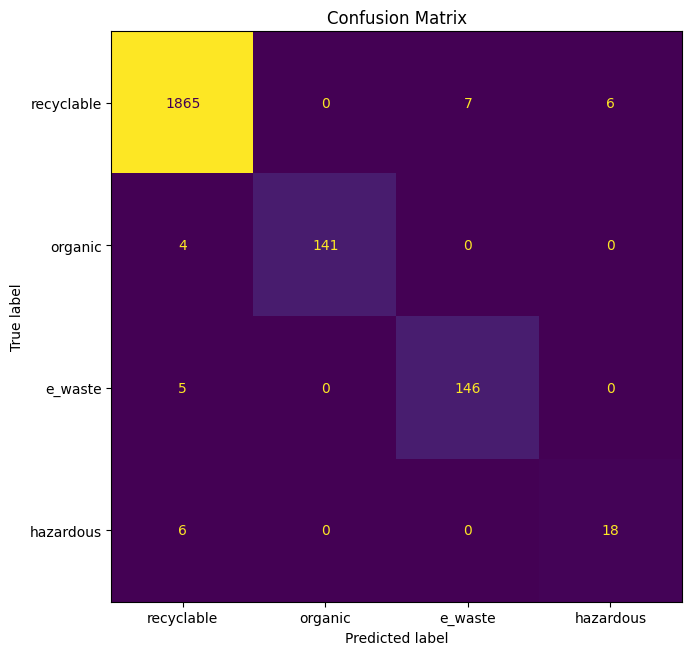

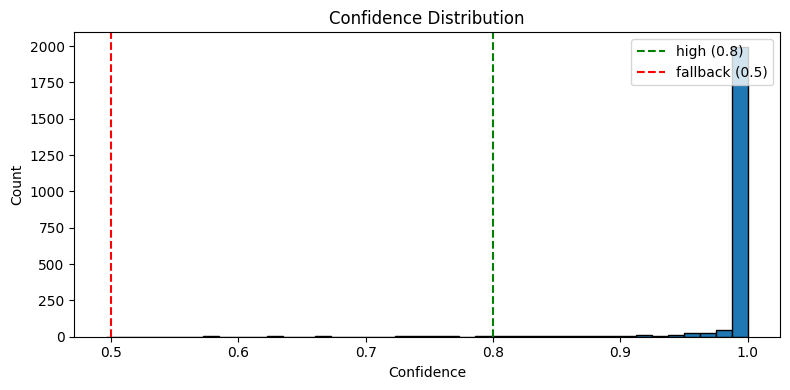

In [8]:
build_merged_dataset()
 
train_loader, val_loader = get_dataloaders()
 
model = build_model(freeze_backbone=True).to(DEVICE)
 
print("\n--- Phase 1: frozen backbone ---")
train_phase(model, train_loader, val_loader, PHASE1_LR, PHASE1_EPOCHS, "P1")
 
# load best checkpoint before phase 2
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
 
print("\n--- Phase 2: unfreeze layer4 ---")
unfreeze_last_block(model)
train_phase(model, train_loader, val_loader, PHASE2_LR, PHASE2_EPOCHS, "P2")
 
# load overall best for evaluation
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
 
print("\n--- Evaluation ---")
preds, labels, confs, routed, n_saved, subclass_stats = evaluate(model, val_loader)
 
acc = sum(p == l for p, l in zip(preds, labels)) / len(labels)
print(f"val accuracy  : {acc:.4f}")
print(f"routing       : {routed}")
print(f"uncertain saved: {n_saved} → {UNCERTAIN_DIR}")
 
print_subclass_breakdown(subclass_stats)
plot_confusion_matrix(labels, preds)
plot_confidence_dist(confs)

In [12]:
import subprocess
subprocess.run(["pip", "install", "onnxruntime", "onnx", "onnxscript", "-q"], check=True)

import os
import torch
import torch.nn as nn
import numpy as np
from torchvision import models
from onnxruntime.quantization import quantize_dynamic, QuantType
from onnxruntime.quantization import shape_inference as ort_shape_inference

CLASSES = ["recyclable", "organic", "e_waste", "hazardous"]
SAVE_PATH = "/kaggle/working/best_model.pth"
ONNX_FP32 = "/kaggle/working/waste_classifier_fp32.onnx"
ONNX_INT8 = "/kaggle/working/waste_classifier_int8.onnx"
ONNX_INFERRED = "/kaggle/working/waste_classifier_fp32_inferred.onnx"

def build_model():
    model = models.resnet50(weights=None)
    model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
    model.load_state_dict(torch.load(SAVE_PATH, map_location="cpu"))
    model.eval()
    return model

def export_onnx(model):
    dummy = torch.randn(1, 3, 224, 224)
    torch.onnx.export(
        model,
        dummy,
        ONNX_FP32,
        opset_version=17,
        input_names=["image"],
        output_names=["logits"],
        dynamic_axes={"image": {0: "batch_size"}, "logits": {0: "batch_size"}},
    )
    print(f"FP32 ONNX saved: {ONNX_FP32} ({os.path.getsize(ONNX_FP32) / 1e6:.1f} MB)")

def quantize_int8():
    try:
        ort_shape_inference.quant_pre_process(
            input_model_path=ONNX_FP32,
            output_model_path=ONNX_INFERRED,
            skip_optimization=False,
        )
        quantize_dynamic(
            model_input=ONNX_INFERRED,
            model_output=ONNX_INT8,
            weight_type=QuantType.QInt8,
        )
        os.remove(ONNX_INFERRED)
        print(f"INT8 ONNX saved: {ONNX_INT8} ({os.path.getsize(ONNX_INT8) / 1e6:.1f} MB)")
        return True
    except Exception as e:
        print(f"INT8 quantization skipped: {e}")
        return False

def verify_onnx():
    import onnxruntime as ort
    for path, tag in [(ONNX_FP32, "FP32"), (ONNX_INT8, "INT8")]:
        if not os.path.exists(path):
            continue
        sess = ort.InferenceSession(path, providers=["CPUExecutionProvider"])
        dummy = np.random.randn(1, 3, 224, 224).astype(np.float32)
        out = sess.run(["logits"], {"image": dummy})[0]
        exp = np.exp(out - out.max(axis=1, keepdims=True))
        probs = exp / exp.sum(axis=1, keepdims=True)
        pred = CLASSES[probs[0].argmax()]
        conf = probs[0].max()
        print(f"[{tag}] OK - pred={pred} conf={conf:.3f}")

model = build_model()
print("model loaded")
export_onnx(model)
int8_success = quantize_int8()
verify_onnx()

print(f"""
Files ready:
  FP32: {ONNX_FP32} - web + Flutter
  INT8: {ONNX_INT8 if int8_success else 'not created'} - Flutter only (smaller)
Classes: {CLASSES}
Input: [1,3,224,224] ImageNet normalized → softmax → argmax
""")

/tmp/ipykernel_55/1519464824.py:27: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0409 20:27:14.558000 55 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


model loaded


W0409 20:27:15.040000 55 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0409 20:27:15.042000 55 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0409 20:27:15.044000 55 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0409 20:27:15.045000 55 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:65: adapt: Asserti

Applied 107 of general pattern rewrite rules.
FP32 ONNX saved: /kaggle/working/waste_classifier_fp32.onnx (0.2 MB)
INT8 quantization skipped: Incomplete symbolic shape inference
[FP32] OK - pred=recyclable conf=0.957

Files ready:
  FP32: /kaggle/working/waste_classifier_fp32.onnx - web + Flutter
  INT8: not created - Flutter only (smaller)
Classes: ['recyclable', 'organic', 'e_waste', 'hazardous']
Input: [1,3,224,224] ImageNet normalized → softmax → argmax



In [13]:
# EfficientNet-B0 starts

In [14]:
import subprocess
subprocess.run(["pip", "install", "timm", "-q"], check=True)
 
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from PIL import Image
import timm
 
 
CLASSES     = ["recyclable", "organic", "e_waste", "hazardous"]
CLASS_INDEX = {c: i for i, c in enumerate(CLASSES)}
MERGED_DIR  = "/kaggle/working/merged_dataset"
SAVE_PATH   = "/kaggle/working/best_efficientnet.pth"
 
CONFIDENCE_HIGH = 0.80
CONFIDENCE_LOW  = 0.50
FALLBACK_CLASS  = "uncertain"
UNCERTAIN_DIR   = "/kaggle/working/uncertain_samples_eff"
 
BATCH_SIZE    = 32
NUM_WORKERS   = 4
VAL_SPLIT     = 0.20
PHASE1_LR     = 1e-3
PHASE1_EPOCHS = 8
PHASE2_LR     = 1e-4
PHASE2_EPOCHS = 4
 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
 

In [15]:

def get_transforms(train=True):
    if train:
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])
    return transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
 
 
class FlatWasteDataset(Dataset):
    def __init__(self, root, transform=None):
        self.transform = transform
        self.samples = []
        for cls in sorted(os.listdir(root)):
            cls_dir = os.path.join(root, cls)
            if not os.path.isdir(cls_dir) or cls not in CLASS_INDEX:
                continue
            idx = CLASS_INDEX[cls]
            for fname in sorted(os.listdir(cls_dir)):
                if fname.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):
                    self.samples.append((os.path.join(cls_dir, fname), idx, cls))
        print(f"dataset: {len(self.samples)} images")
 
    def __len__(self):
        return len(self.samples)
 
    def __getitem__(self, idx):
        path, label, cls_name = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label, cls_name
 
 
def collate_fn(batch):
    images, labels, names = zip(*batch)
    return torch.stack(images), torch.tensor(labels), list(names)
 
 
def get_dataloaders():
    train_ds = FlatWasteDataset(MERGED_DIR, transform=get_transforms(train=True))
    val_ds   = FlatWasteDataset(MERGED_DIR, transform=get_transforms(train=False))
    n_val    = int(len(train_ds) * VAL_SPLIT)
    indices  = torch.randperm(len(train_ds)).tolist()
    train_loader = DataLoader(
        Subset(train_ds, indices[n_val:]),
        batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn,
    )
    val_loader = DataLoader(
        Subset(val_ds, indices[:n_val]),
        batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True, collate_fn=collate_fn,
    )
    return train_loader, val_loader
 
 
def build_model(freeze_backbone=True):
    model = timm.create_model("efficientnet_b0", pretrained=True)
    model.classifier = nn.Linear(model.classifier.in_features, len(CLASSES))
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
        for param in model.classifier.parameters():
            param.requires_grad = True
    return model
 
 
def unfreeze_last_block(model):
    for param in model.blocks[-1].parameters():
        param.requires_grad = True
    for param in model.classifier.parameters():
        param.requires_grad = True
 
 
def run_epoch(model, loader, criterion, optimizer, training):
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for images, labels, _ in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            correct    += (outputs.argmax(dim=1) == labels).sum().item()
            total      += images.size(0)
    return total_loss / total, correct / total
 
 
def train_phase(model, train_loader, val_loader, lr, epochs, tag):
    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = StepLR(optimizer, step_size=3, gamma=0.5)
    best_val_acc = 0.0
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, True)
        vl_loss, vl_acc = run_epoch(model, val_loader,   criterion, None,      False)
        scheduler.step()
        print(f"[{tag}] {epoch}/{epochs} "
              f"train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} "
              f"val_loss={vl_loss:.4f} val_acc={vl_acc:.4f}")
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            torch.save(model.state_dict(), SAVE_PATH)
            print(f"  checkpoint saved val_acc={vl_acc:.4f}")
    return best_val_acc
 
 

In [16]:
 
def route(conf, pred_idx):
    if conf >= CONFIDENCE_HIGH:
        return CLASSES[pred_idx], "high"
    elif conf >= CONFIDENCE_LOW:
        return CLASSES[pred_idx], "uncertain"
    return FALLBACK_CLASS, "fallback"
 
 
def save_uncertain_image(tensor, idx, tier):
    os.makedirs(UNCERTAIN_DIR, exist_ok=True)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img  = (tensor.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    import matplotlib.pyplot as plt
    plt.imsave(os.path.join(UNCERTAIN_DIR, f"{tier}_{idx:05d}.png"), img)
 
 
def evaluate(model, val_loader):
    import numpy as np
    from collections import defaultdict
    import matplotlib.pyplot as plt
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
 
    model.eval()
    all_preds, all_labels, all_confs = [], [], []
    routed = {"high": 0, "uncertain": 0, "fallback": 0}
    subclass_stats = defaultdict(lambda: {"correct": 0, "total": 0})
    n_saved = 0
 
    with torch.no_grad():
        for b_idx, (images, labels, cls_names) in enumerate(val_loader):
            images = images.to(DEVICE)
            probs  = F.softmax(model(images), dim=1)
            confs, preds = probs.max(dim=1)
            for i in range(images.size(0)):
                conf, pred, label = confs[i].item(), preds[i].item(), labels[i].item()
                _, tier = route(conf, pred)
                if tier in ("uncertain", "fallback"):
                    save_uncertain_image(images[i], b_idx * BATCH_SIZE + i, tier)
                    n_saved += 1
                routed[tier] += 1
                subclass_stats[cls_names[i]]["total"]   += 1
                subclass_stats[cls_names[i]]["correct"] += int(pred == label)
                all_preds.append(pred)
                all_labels.append(label)
                all_confs.append(conf)
 
    acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    print(f"val accuracy: {acc:.4f}")
    print(f"routing: {routed}")
    print(f"uncertain saved: {n_saved}")
 
    print(f"\n{'class':<16} {'correct':>8} {'total':>8} {'acc':>8}")
    print("-" * 44)
    for name in sorted(subclass_stats):
        s = subclass_stats[name]
        a = s["correct"] / s["total"] if s["total"] else 0.0
        print(f"{name:<16} {s['correct']:>8} {s['total']:>8} {a:>8.4f}")
 
   
    cm   = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
    fig, ax = plt.subplots(figsize=(7, 7))
    disp.plot(ax=ax, colorbar=False)
    plt.title("EfficientNet-B0 Confusion Matrix")
    plt.tight_layout()
    plt.savefig("/kaggle/working/efficientnet_confusion_matrix.png", dpi=150)
    plt.show()
 
    # confidence distribution
    plt.figure(figsize=(8, 4))
    plt.hist(all_confs, bins=40, edgecolor="black")
    plt.axvline(CONFIDENCE_HIGH, color="green", linestyle="--", label=f"high ({CONFIDENCE_HIGH})")
    plt.axvline(CONFIDENCE_LOW,  color="red",   linestyle="--", label=f"fallback ({CONFIDENCE_LOW})")
    plt.xlabel("Confidence")
    plt.ylabel("Count")
    plt.title("EfficientNet-B0 Confidence Distribution")
    plt.legend()
    plt.tight_layout()
    plt.savefig("/kaggle/working/efficientnet_confidence_dist.png", dpi=150)
    plt.show()
 
    # per-class accuracy bar chart
    class_accs = []
    for cls in CLASSES:
        s = subclass_stats[cls]
        class_accs.append(s["correct"] / s["total"] if s["total"] else 0.0)
    plt.figure(figsize=(7, 4))
    plt.bar(CLASSES, class_accs, edgecolor="black")
    plt.ylim(0, 1)
    plt.ylabel("Accuracy")
    plt.title("Per-class Accuracy")
    plt.tight_layout()
    plt.savefig("/kaggle/working/efficientnet_per_class_acc.png", dpi=150)
    plt.show()
 

In [17]:
# export
 
def export_onnx(model):
    import subprocess
    subprocess.run(["pip", "install", "onnxruntime", "onnx", "-q"], check=True)
    import onnx
    from onnxruntime.quantization import quantize_dynamic, QuantType
    from onnxruntime.quantization import shape_inference as ort_shape
 
    ONNX_FP32     = "/kaggle/working/efficientnet_fp32.onnx"
    ONNX_INT8     = "/kaggle/working/efficientnet_int8.onnx"
    ONNX_INFERRED = "/kaggle/working/efficientnet_fp32_inferred.onnx"
 
    model.eval().cpu()
    dummy = torch.randn(1, 3, 224, 224)
    torch.onnx.export(
        model, dummy, ONNX_FP32,
        opset_version=17,
        input_names=["image"],
        output_names=["logits"],
        dynamic_axes={"image": {0: "batch_size"}, "logits": {0: "batch_size"}},
    )
    print(f"FP32 saved: {ONNX_FP32} ({os.path.getsize(ONNX_FP32)/1e6:.1f} MB)")
 
    try:
        ort_shape.quant_pre_process(ONNX_FP32, ONNX_INFERRED, skip_optimization=False)
        quantize_dynamic(model_input=ONNX_INFERRED, model_output=ONNX_INT8, weight_type=QuantType.QInt8)
        os.remove(ONNX_INFERRED)
        print(f"INT8 saved: {ONNX_INT8} ({os.path.getsize(ONNX_INT8)/1e6:.1f} MB)")
    except Exception as e:
        print(f"INT8 quantization failed: {e}")
        print("FP32 is fully usable for Flutter and web.")
 
    # verify
    import onnxruntime as ort
    import numpy as np
    for path, tag in [(ONNX_FP32, "FP32"), (ONNX_INT8, "INT8")]:
        if not os.path.exists(path):
            continue
        sess  = ort.InferenceSession(path, providers=["CPUExecutionProvider"])
        out   = sess.run(["logits"], {"image": np.random.randn(1, 3, 224, 224).astype(np.float32)})[0]
        exp   = np.exp(out - out.max(axis=1, keepdims=True))
        probs = exp / exp.sum(axis=1, keepdims=True)
        print(f"[{tag}] verify pred={CLASSES[probs[0].argmax()]} conf={probs[0].max():.4f} (random input)")
 
    print(f"input:  float32 [1, 3, 224, 224] ImageNet normalised")
    print(f"output: float32 [1, 4] logits -> softmax -> argmax")
    print(f"classes: {CLASSES}")
 

dataset: 10992 images
dataset: 10992 images


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Phase 1: frozen backbone
[P1] 1/8 train_loss=0.2755 train_acc=0.9273 val_loss=0.2257 val_acc=0.9440
  checkpoint saved val_acc=0.9440
[P1] 2/8 train_loss=0.1634 train_acc=0.9545 val_loss=0.1762 val_acc=0.9540
  checkpoint saved val_acc=0.9540
[P1] 3/8 train_loss=0.1323 train_acc=0.9618 val_loss=0.1739 val_acc=0.9504
[P1] 4/8 train_loss=0.1211 train_acc=0.9618 val_loss=0.1635 val_acc=0.9554
  checkpoint saved val_acc=0.9554
[P1] 5/8 train_loss=0.1123 train_acc=0.9655 val_loss=0.1655 val_acc=0.9504
[P1] 6/8 train_loss=0.1111 train_acc=0.9690 val_loss=0.1496 val_acc=0.9591
  checkpoint saved val_acc=0.9591
[P1] 7/8 train_loss=0.1056 train_acc=0.9691 val_loss=0.1434 val_acc=0.9609
  checkpoint saved val_acc=0.9609
[P1] 8/8 train_loss=0.1033 train_acc=0.9694 val_loss=0.1495 val_acc=0.9600
Phase 2: unfreeze last block
[P2] 1/4 train_loss=0.0887 train_acc=0.9734 val_loss=0.0995 val_acc=0.9741
  checkpoint saved val_acc=0.9741
[P2] 2/4 train_loss=0.0707 train_acc=0.9769 val_loss=0.0746 val_acc

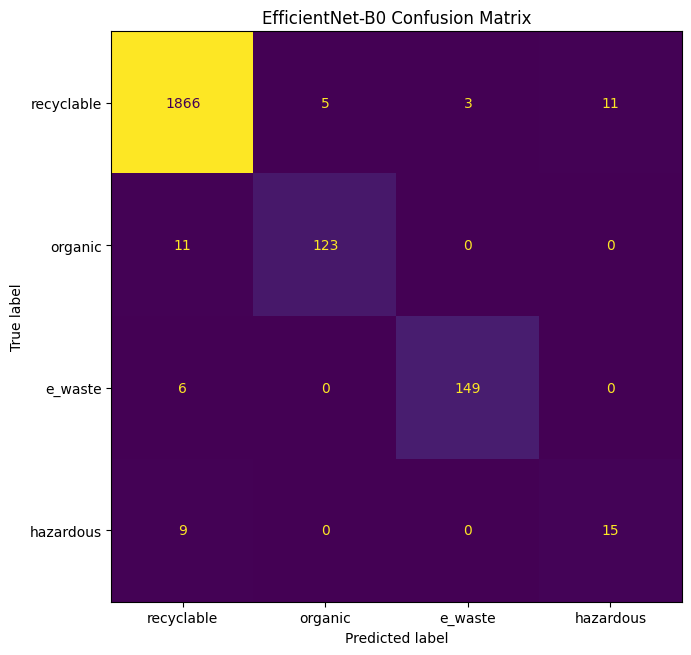

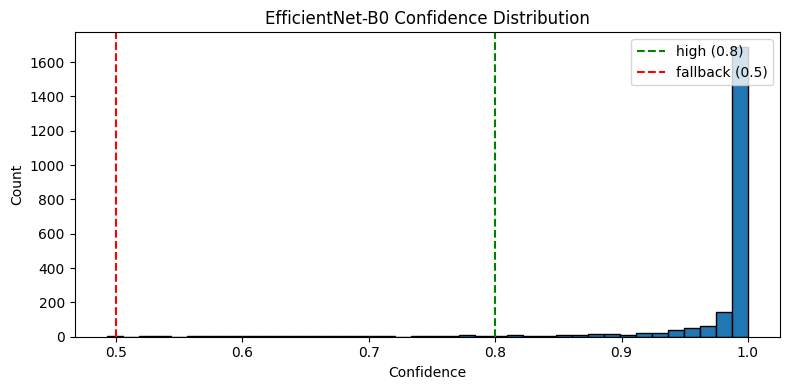

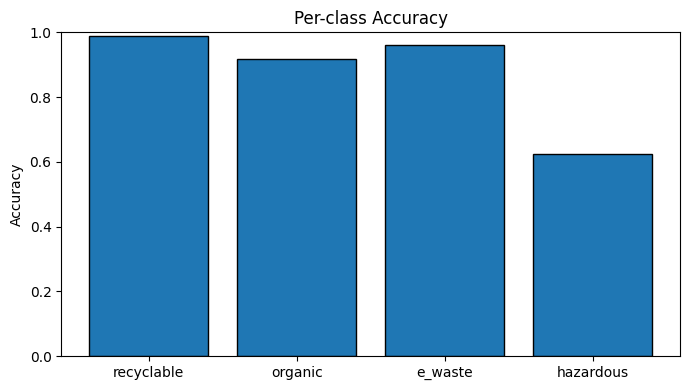

Exporting ONNX


/tmp/ipykernel_55/4114651291.py:16: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0409 20:47:55.471000 55 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0409 20:47:55.955000 55 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned

[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:65: adapt: Asserti

Applied 99 of general pattern rewrite rules.
FP32 saved: /kaggle/working/efficientnet_fp32.onnx (0.5 MB)
INT8 quantization failed: Incomplete symbolic shape inference
FP32 is fully usable for Flutter and web.
[FP32] verify pred=recyclable conf=1.0000 (random input)
input:  float32 [1, 3, 224, 224] ImageNet normalised
output: float32 [1, 4] logits -> softmax -> argmax
classes: ['recyclable', 'organic', 'e_waste', 'hazardous']


In [18]:
# main
 
train_loader, val_loader = get_dataloaders()
 
model = build_model(freeze_backbone=True).to(DEVICE)
 
print("Phase 1: frozen backbone")
train_phase(model, train_loader, val_loader, PHASE1_LR, PHASE1_EPOCHS, "P1")
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
 
print("Phase 2: unfreeze last block")
unfreeze_last_block(model)
train_phase(model, train_loader, val_loader, PHASE2_LR, PHASE2_EPOCHS, "P2")
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
 
print("Evaluation")
evaluate(model, val_loader)
 
print("Exporting ONNX")
export_onnx(model)